In [156]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
import os

In [157]:
load_dotenv()

True

In [158]:
model = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url= os.getenv("GROQ_BASE_URL"),
    max_tokens=500,
    temperature=0.5
)

In [159]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='score out of 10', ge=0, le=10)

In [160]:
structured_model = model.with_structured_output(EvaluationSchema)

In [161]:
essay = """
Artificial Intelligence (AI) is no longer a futuristic concept; it is rapidly becoming a transformative force in India's economy and society. From healthcare and agriculture to education, governance, and industry, AI has the potential to address some of India's most complex challenges while creating new opportunities for growth. However, its success will depend not merely on technological advancement, but on India's ability to develop AI that is inclusive, ethical, secure, and accessible to all.

One of the most promising applications of AI in India is **healthcare**. India has a vast population and significant differences in access to medical facilities between urban and rural regions. AI can assist doctors by analyzing medical images, identifying patterns in patient data, and supporting early disease detection. In areas where specialists are scarce, AI-assisted diagnostic systems could help extend the reach of medical expertise. Importantly, AI should complement rather than replace healthcare professionals, with human judgment remaining central to sensitive medical decisions.

**Agriculture**, which supports the livelihoods of millions of Indians, is another sector where AI can create meaningful impact. AI systems can combine information about weather, soil conditions, satellite imagery, and crop health to help farmers make better decisions. Early detection of crop diseases can reduce losses, while intelligent irrigation systems can help conserve water. Such applications demonstrate that the value of AI is not limited to sophisticated technology; it can directly contribute to improving productivity and the livelihoods of ordinary citizens.

AI is equally significant in **education**. India's diverse student population has widely varying learning needs. AI-powered educational tools can provide personalized explanations, identify areas where students struggle, and recommend appropriate learning material. Teachers can also use AI to reduce administrative workloads and spend more time interacting with students. Nevertheless, excessive dependence on AI could weaken critical thinking and independent learning. Therefore, AI should be treated as a learning assistant rather than a substitute for teachers or students' own intellectual effort.

In the **business and industrial sectors**, AI is already changing the way organizations operate. Companies can use AI for forecasting demand, detecting fraud, improving customer service, automating repetitive tasks, and analyzing large amounts of data. In manufacturing, AI can identify defects and predict equipment failures before they occur. These capabilities can improve productivity and make Indian businesses more competitive in the global economy.

AI can also strengthen **governance and public services**. Governments handle enormous quantities of information, and AI can help analyze this data more efficiently. Applications in areas such as traffic management, disaster prediction, public-service delivery, and document processing could make government systems faster and more responsive. However, the use of AI in governance requires particular caution because decisions affecting citizens must be transparent, accountable, and free from unfair discrimination.

Despite its enormous potential, AI presents serious **challenges**. Automation may reduce demand for certain repetitive jobs, making reskilling and lifelong learning increasingly important. AI systems can also reproduce biases present in their training data, while the collection and processing of large amounts of personal information raises concerns about privacy and security. The spread of AI-generated misinformation presents another challenge, particularly in a country as large and diverse as India.

India's linguistic and cultural diversity makes the development of **inclusive AI** especially important. AI systems designed primarily for English-speaking users may fail to serve millions of Indians who communicate in other languages. Building reliable AI capabilities across Indian languages can help ensure that the benefits of technological progress are not restricted to digitally privileged communities.

Ultimately, India's AI journey should not be measured simply by the number of AI models developed or companies adopting the technology. Its real success should be measured by whether AI improves people's lives, expands economic opportunities, strengthens public services, and reduces rather than deepens existing inequalities. This requires investment in education, research, digital infrastructure, ethical standards, data protection, and workforce reskilling.

In conclusion, **AI represents both an opportunity and a responsibility for India**. It can accelerate economic growth, improve essential services, and help solve problems that affect millions of people. At the same time, unchecked adoption could create new forms of inequality, unemployment, and technological dependence. India therefore needs an approach that combines innovation with human values and responsible governance. If this balance is achieved, AI can become not merely a symbol of technological progress, but a powerful instrument for building a more inclusive, productive, and resilient India.

"""

In [162]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
ans = structured_model.invoke(prompt)

In [163]:
ans

EvaluationSchema(feedback='The essay demonstrates solid language proficiency with clear, well‑structured paragraphs and effective use of headings. The vocabulary is appropriate for an academic audience, and the writer maintains a formal tone throughout. Minor issues include occasional repetition (e.g., “AI can” appears frequently) and a few awkward phrasings such as “AI should complement rather than replace healthcare professionals, with human judgment remaining central to sensitive medical decisions.” The punctuation is generally correct, but there are a few places where commas could improve readability. Overall, the essay is coherent, logically organized, and persuasive, but could benefit from tighter editing to eliminate redundancy and polish sentence structure.', score=8)

In [164]:
ans.feedback

'The essay demonstrates solid language proficiency with clear, well‑structured paragraphs and effective use of headings. The vocabulary is appropriate for an academic audience, and the writer maintains a formal tone throughout. Minor issues include occasional repetition (e.g., “AI can” appears frequently) and a few awkward phrasings such as “AI should complement rather than replace healthcare professionals, with human judgment remaining central to sensitive medical decisions.” The punctuation is generally correct, but there are a few places where commas could improve readability. Overall, the essay is coherent, logically organized, and persuasive, but could benefit from tighter editing to eliminate redundancy and polish sentence structure.'

In [165]:
ans.score

8

In [166]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [167]:
def evaluate_language(state: UPSCState):

    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"

    output = structured_model.invoke(prompt)

    return {
        'language_feedback': output.feedback, 
        'individual_scores': [output.score]
    }

In [168]:
def evaluate_analysis(state: UPSCState):

    prompt = f"Evaluate the depth of the analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"

    output = structured_model.invoke(prompt)

    return {
        'analysis_feedback': output.feedback, 
        'individual_scores': [output.score]
    }

In [169]:
def evaluate_thought(state: UPSCState):

    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"

    output = structured_model.invoke(prompt)

    return {
        'clarity_feedback': output.feedback, 
        'individual_scores': [output.score]
    }

In [170]:
def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
    

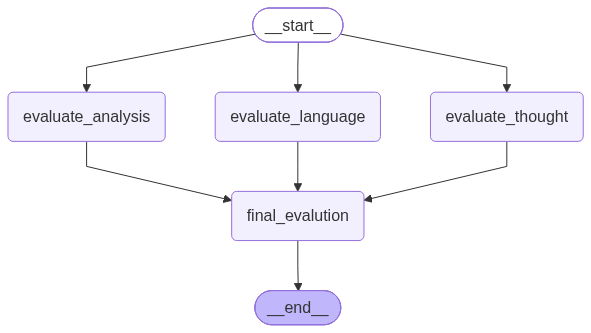

In [171]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evalution', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evalution')
graph.add_edge('evaluate_analysis', 'final_evalution')
graph.add_edge('evaluate_thought', 'final_evalution')

graph.add_edge('final_evalution', END)


workflow = graph.compile()

workflow



In [172]:
initial_state = {'essay': essay}

workflow.invoke(initial_state)

{'essay': "\nArtificial Intelligence (AI) is no longer a futuristic concept; it is rapidly becoming a transformative force in India's economy and society. From healthcare and agriculture to education, governance, and industry, AI has the potential to address some of India's most complex challenges while creating new opportunities for growth. However, its success will depend not merely on technological advancement, but on India's ability to develop AI that is inclusive, ethical, secure, and accessible to all.\n\nOne of the most promising applications of AI in India is **healthcare**. India has a vast population and significant differences in access to medical facilities between urban and rural regions. AI can assist doctors by analyzing medical images, identifying patterns in patient data, and supporting early disease detection. In areas where specialists are scarce, AI-assisted diagnostic systems could help extend the reach of medical expertise. Importantly, AI should complement rather

In [173]:
bad_essay = """
AI is very good and AI is very important in India. AI can do many things and it is used everywhere. India is using AI because AI is future and future is AI.

AI is used in healthcare and agriculture and education. In healthcare AI can help doctors and it can also do doctor work. In agriculture AI can help farmers because farmers need AI. AI can tell about crops and weather and many things. In education students can use AI to study but sometimes students use AI for everything which is not good.

AI also helps companies because companies can use AI and save time. But AI can take jobs also. People will lose jobs because AI is doing jobs of people. This is bad but AI is also good. So AI is good and bad both.

India should use AI because other countries are using AI. If India does not use AI then India will be behind. The government should make AI better and people should learn AI. AI is important for India and India should use AI for development.

In conclusion, AI is very important and useful. AI has many advantages and some disadvantages also. India should use AI because AI is the future and the future is AI.

"""

In [174]:
initial_state = {'essay': bad_essay}

workflow.invoke(initial_state)

{'essay': '\nAI is very good and AI is very important in India. AI can do many things and it is used everywhere. India is using AI because AI is future and future is AI.\n\nAI is used in healthcare and agriculture and education. In healthcare AI can help doctors and it can also do doctor work. In agriculture AI can help farmers because farmers need AI. AI can tell about crops and weather and many things. In education students can use AI to study but sometimes students use AI for everything which is not good.\n\nAI also helps companies because companies can use AI and save time. But AI can take jobs also. People will lose jobs because AI is doing jobs of people. This is bad but AI is also good. So AI is good and bad both.\n\nIndia should use AI because other countries are using AI. If India does not use AI then India will be behind. The government should make AI better and people should learn AI. AI is important for India and India should use AI for development.\n\nIn conclusion, AI is 